## Data of European residents traveling to Switzerland

In [2]:
# import modules
import pandas as pd
import numpy as np
import json
from pyjstat import pyjstat
import matplotlib.pyplot as plt

In [3]:
# read dataset: https://www.pxweb.bfs.admin.ch/pxweb/en/px-x-1003020000_102/px-x-1003020000_102/px-x-1003020000_102.px/table/tableViewLayout2/
# Hotel sector: arrivals and overnight stays of open establishments by Year, Month, Canton, Visitors' country of residence and Indicator
with open("px-x-1003020000_102_20260317-180818.json", "r", encoding="utf-8") as f:
    data = json.load(f)

dataset = pyjstat.from_json_stat(data)

eu_to_ch_df = dataset[0]
# eu_to_ch_df = eu_to_ch_df.dropna()

eu_to_ch_df.loc[:, "Visitors' country of residence"] = eu_to_ch_df["Visitors' country of residence"].replace("Irland", "Ireland")
eu_to_ch_df = eu_to_ch_df.rename(columns={"Month": "TIME_SEQ"})

eu_to_ch_df

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
1,2005,Total of the year,Switzerland,Visitors' country of residence - total,Overnight stays,32943736.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
3,2005,Total of the year,Switzerland,Switzerland,Overnight stays,14622420.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
...,...,...,...,...,...,...
1204627,2026,December,Jura,Czechia,Overnight stays,NaN
1204628,2026,December,Jura,Ukraine,Arrivals,NaN
1204629,2026,December,Jura,Ukraine,Overnight stays,NaN
1204630,2026,December,Jura,Serbia,Arrivals,NaN


In [4]:
# Here we check year 2025 data
data_df = dataset[0].dropna()
data_df[(data_df["Year"]=="2025") & (data_df["Canton"]=="Switzerland") & (data_df["Indicator"]=="Arrivals")]

,Year,Month,Canton,Visitors' country of residence,Indicator,value
1095120,2025,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,22173712.0
1095122,2025,Total of the year,Switzerland,Switzerland,Arrivals,11119049.0
1095126,2025,Total of the year,Switzerland,Germany,Arrivals,1779401.0
1095128,2025,Total of the year,Switzerland,France,Arrivals,871032.0
1095130,2025,Total of the year,Switzerland,Italy,Arrivals,495151.0
...,...,...,...,...,...,...
1145810,2025,December,Switzerland,Slovakia,Arrivals,1287.0
1145812,2025,December,Switzerland,Slovenia,Arrivals,988.0
1145814,2025,December,Switzerland,Czechia,Arrivals,3811.0
1145816,2025,December,Switzerland,Ukraine,Arrivals,5618.0


In [5]:
data_df[(data_df["Year"]=="2025") & (data_df["Month"]=="Total of the year") & (data_df["Indicator"]=="Arrivals")]

,Year,Month,Canton,Visitors' country of residence,Indicator,value
1095120,2025,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,22173712.0
1095122,2025,Total of the year,Switzerland,Switzerland,Arrivals,11119049.0
1095126,2025,Total of the year,Switzerland,Germany,Arrivals,1779401.0
1095128,2025,Total of the year,Switzerland,France,Arrivals,871032.0
1095130,2025,Total of the year,Switzerland,Italy,Arrivals,495151.0
...,...,...,...,...,...,...
1099322,2025,Total of the year,Jura,Slovakia,Arrivals,7.0
1099324,2025,Total of the year,Jura,Slovenia,Arrivals,8.0
1099326,2025,Total of the year,Jura,Czechia,Arrivals,31.0
1099328,2025,Total of the year,Jura,Ukraine,Arrivals,13.0


In [6]:
# filter data for European residents traveling to Switzerland
# annual data
eu_to_ch_filtered_df = eu_to_ch_df[(eu_to_ch_df["TIME_SEQ"]=="Total of the year") & (eu_to_ch_df["Indicator"]=="Arrivals") & (eu_to_ch_df["Canton"]=="Switzerland")]

eu_to_ch_filtered_df.head(20)

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
0,2005,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,13802796.0
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
4,2005,Total of the year,Switzerland,Baltic States,Arrivals,13115.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
12,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0
14,2005,Total of the year,Switzerland,United Kingdom,Arrivals,709155.0
16,2005,Total of the year,Switzerland,Ireland,Arrivals,25278.0
18,2005,Total of the year,Switzerland,Netherlands,Arrivals,312546.0


In [7]:
eu_to_ch_filtered_df = eu_to_ch_filtered_df.copy()

eu_to_ch_filtered_df.loc[:, "Year"] = pd.to_numeric(
    eu_to_ch_filtered_df["Year"],
    errors="coerce"
)
eu_to_ch_arrival_2020_2026 = eu_to_ch_filtered_df[(eu_to_ch_filtered_df["Year"] >= 2020) & (eu_to_ch_filtered_df["Year"] <= 2026)]
eu_to_ch_arrival_2020_2026

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,value
821340,2020,Total of the year,Switzerland,Visitors' country of residence - total,Arrivals,10703428.0
821342,2020,Total of the year,Switzerland,Switzerland,Arrivals,7694605.0
821344,2020,Total of the year,Switzerland,Baltic States,Arrivals,NaN
821346,2020,Total of the year,Switzerland,Germany,Arrivals,885226.0
821348,2020,Total of the year,Switzerland,France,Arrivals,414385.0
...,...,...,...,...,...,...
1150022,2026,Total of the year,Switzerland,Slovakia,Arrivals,NaN
1150024,2026,Total of the year,Switzerland,Slovenia,Arrivals,NaN
1150026,2026,Total of the year,Switzerland,Czechia,Arrivals,NaN
1150028,2026,Total of the year,Switzerland,Ukraine,Arrivals,NaN


In [8]:
# filter Arrivals, Total of the year, each Canton
filtered = eu_to_ch_df[
    (eu_to_ch_df["TIME_SEQ"] == "Total of the year") &
    (eu_to_ch_df["Indicator"] == "Arrivals") &
    (eu_to_ch_df["Visitors' country of residence"] == "Visitors' country of residence - total")
][["Year", "Canton", "value"]]

result = {}
for year, group in filtered.groupby("Year"):
    result[int(year)] = dict(zip(group["Canton"], group["value"]))
    
name_fix = {
    "Zurich": "Zürich",
    "Lucerne": "Luzern",
    "Geneva": "Genève"
    # "Graubunden": "Graubünden",
    # "Neuchatel": "Neuchâtel",
}

# fix each year traget cantons names
for year in result:
    result[year] = {name_fix.get(k, k): v for k, v in result[year].items()}
    
with open("canton_annual_total_visitors.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(result)

{2005: {'Switzerland': 13802796.0, 'Zürich': 1957324.0, 'Bern': 1920624.0, 'Luzern': 749485.0, 'Uri': 118748.0, 'Schwyz': 266473.0, 'Obwalden': 216633.0, 'Nidwalden': 147961.0, 'Glarus': 59499.0, 'Zug': 102781.0, 'Fribourg': 193381.0, 'Solothurn': 162130.0, 'Basel-Stadt': 374262.0, 'Basel-Landschaft': 102091.0, 'Schaffhausen': 65027.0, 'Appenzell Ausserrhoden': 55586.0, 'Appenzell Innerrhoden': 77182.0, 'St. Gallen': 413632.0, 'Graubünden': 1696711.0, 'Aargau': 254839.0, 'Thurgau': 183709.0, 'Ticino': 1079287.0, 'Vaud': 977457.0, 'Valais': 1375877.0, 'Neuchâtel': 109397.0, 'Genève': 1094005.0, 'Jura': 48695.0}, 2006: {'Switzerland': 14811349.0, 'Zürich': 2118973.0, 'Bern': 2060637.0, 'Luzern': 830587.0, 'Uri': 125585.0, 'Schwyz': 284569.0, 'Obwalden': 255421.0, 'Nidwalden': 140995.0, 'Glarus': 63191.0, 'Zug': 111626.0, 'Fribourg': 200127.0, 'Solothurn': 175309.0, 'Basel-Stadt': 424858.0, 'Basel-Landschaft': 106958.0, 'Schaffhausen': 69148.0, 'Appenzell Ausserrhoden': 58902.0, 'Appenzel

In [9]:
!pip install geopandas

In [10]:
import geopandas as gpd

gdf = gpd.read_file("swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET.shp", encoding="utf-8")
print(gdf.columns.tolist())  # check columns
gdf = gdf.set_crs(epsg=2056)
gdf = gdf.to_crs(epsg=4326)
gdf.to_file("cantons.geojson", driver="GeoJSON")

['UUID', 'DATUM_AEND', 'DATUM_ERST', 'ERSTELL_J', 'ERSTELL_M', 'GRUND_AEND', 'HERKUNFT', 'HERKUNFT_J', 'HERKUNFT_M', 'REVISION_J', 'REVISION_M', 'REVISION_Q', 'OBJEKTART', 'KANTONSNUM', 'SEE_FLAECH', 'KANTONSFLA', 'NAME', 'ICC', 'EINWOHNERZ', 'geometry']


## European Countries GDP

In [12]:
# list of European countries (here, in total 51 countries)
eu_countries = ["Albania", "Andorra", "Armenia", "Austria", "Azerbaijan",
                "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
                "Croatia", "Cyprus", "Czechia",
                "Denmark",
                "Estonia",
                "Finland", "France",
                "Georgia", "Germany", "Greece",
                "Hungary",
                "Iceland", "Ireland", "Italy",
                "Kazakhstan", "Kosovo",
                "Latvia", "Liechtenstein", "Lithuania", "Luxembourg",
                "Malta", "Moldova", "Monaco", "Montenegro",
                "Netherlands", "North Macedonia", "Norway",
                "Poland", "Portugal",
                "Romania", "Russia",
                "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland",
                "Turkey",
                "Ukraine", "United Kingdom",
                "Vatican City"]

In [13]:
len(eu_countries)

51

In [14]:
# read dataset: https://ec.europa.eu/eurostat/databrowser/view/sdg_10_10/default/table?lang=en
# Purchasing power adjusted GDP per capita
gdp_ppp_df = pd.read_csv("ppp_adj_gdp_per_capita.csv")

# drop unused columns
gdp_ppp_df = gdp_ppp_df.drop(columns={"STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "freq", "Time frequency", "Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18)",
                                      "geo", "Time", "Observation value", "Observation status (Flag) V2 structure", "Confidentiality status (flag)"})

In [15]:
# check countries with GDP values that are (e)estimated or (p)provisional
gdp_ppp_df[gdp_ppp_df["OBS_FLAG"].isin(["e", "p"])].head()

,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
25,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,Euro area – 20 countries (2023-2025),2025,42.3,p,NaN
26,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,Euro area – 21 countries (from 2026),2025,42.8,p,NaN
52,CV_VI_HAB,Coefficient of variation of volume indices of ...,GDP,PC,Percentage,European Union - 27 countries (from 2020),2025,40.1,p,NaN
77,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2024,16700.0,p,NaN
103,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Austria,2025,48900.0,p,NaN


In [16]:
# rename column Geopolitical entity (reporting) as country
# drop columns OBS_FLAG and CONF_STATUS
gdp_ppp_df = gdp_ppp_df.rename(columns={"Geopolitical entity (reporting)":"country"}).drop(columns={"OBS_FLAG", "CONF_STATUS"})
gdp_ppp_df["country"] = gdp_ppp_df["country"].replace("Türkiye", "Turkey")

eu_gdp_ppp_df = gdp_ppp_df[gdp_ppp_df["country"].isin(eu_countries)]
eu_gdp_ppp_df.head()
eu_gdp_ppp_df["country"].unique()

array(['Albania', 'Austria', 'Bosnia and Herzegovina', 'Belgium',
       'Bulgaria', 'Switzerland', 'Cyprus', 'Czechia', 'Germany',
       'Denmark', 'Estonia', 'Greece', 'Spain', 'Finland', 'France',
       'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy', 'Lithuania',
       'Luxembourg', 'Latvia', 'Montenegro', 'North Macedonia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia',
       'Sweden', 'Slovenia', 'Slovakia', 'Turkey', 'United Kingdom'],
      dtype=object)

In [17]:
eu_gdp_ppp_df

,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,country,TIME_PERIOD,OBS_VALUE
53,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2000,3300.0
54,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2001,3700.0
55,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2002,4000.0
56,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2003,4200.0
57,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,Albania,2004,4600.0
...,...,...,...,...,...,...,...,...
2109,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2020,102.0
2110,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2021,100.0
2111,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2022,103.0
2112,VI_PPS_EU27_2020_HAB,Volume indices of real expenditure per capita ...,GDP,PC,Percentage,United Kingdom,2023,99.0


In [18]:
eu_to_ch_filtered_df.loc[:, "Year"] = eu_to_ch_filtered_df["Year"].astype(int)

eu_gdp_ppp_filtered_df = eu_gdp_ppp_df[eu_gdp_ppp_df["Purchasing power parities indicator"]=="Real expenditure per capita (in PPS_EU27_2020)"]

eu_gdp_and_to_ch_df = pd.merge(eu_to_ch_filtered_df, eu_gdp_ppp_filtered_df,
                               left_on=["Visitors' country of residence", "Year"], right_on=["country", "TIME_PERIOD"],
                               how="left")

eu_gdp_and_to_ch_df
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.drop(columns={"country", "TIME_PERIOD"})

eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.dropna()
eu_gdp_and_to_ch_df = eu_gdp_and_to_ch_df.rename(columns={"value": "num_of_visitors", "OBS_VALUE": "gdp_pps"})

eu_gdp_and_to_ch_df.head(50)
# from here we can see that each country's GDP per capita (PPS) values are duplicated because we merge the monthly number of visitors from European countries to Switzerland with annual GDP 

,Year,TIME_SEQ,Canton,Visitors' country of residence,Indicator,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps
1,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0
3,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0
4,2005,Total of the year,Switzerland,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0
5,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0
6,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0
7,2005,Total of the year,Switzerland,United Kingdom,Arrivals,709155.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26900.0
8,2005,Total of the year,Switzerland,Ireland,Arrivals,25278.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,33100.0
9,2005,Total of the year,Switzerland,Netherlands,Arrivals,312546.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,30900.0
10,2005,Total of the year,Switzerland,Belgium,Arrivals,207644.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,27200.0
11,2005,Total of the year,Switzerland,Luxembourg,Arrivals,35309.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,56300.0


In [19]:
eu_gdp_and_to_ch_df["Visitors' country of residence"].unique()

array(['Switzerland', 'Germany', 'France', 'Italy', 'Austria',
       'United Kingdom', 'Ireland', 'Netherlands', 'Belgium',
       'Luxembourg', 'Denmark', 'Sweden', 'Norway', 'Finland', 'Spain',
       'Portugal', 'Greece', 'Turkey', 'Iceland', 'Poland', 'Hungary',
       'Bulgaria', 'Croatia', 'Romania', 'Slovakia', 'Slovenia',
       'Czechia', 'Malta', 'Cyprus', 'Estonia', 'Latvia', 'Lithuania',
       'Serbia'], dtype=object)

In [20]:
len(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())

33

In [21]:
eu_gdp_and_to_ch_df.describe()

,num_of_visitors,gdp_pps
count,6.570000e+02,657.000000
mean,4.190734e+05,30787.823440
std,1.472812e+06,14494.274657
min,1.137000e+03,7900.000000
25%,1.264000e+04,20900.000000
50%,3.977700e+04,28700.000000
75%,1.881120e+05,36100.000000
max,1.094049e+07,99300.000000


In [22]:
# sum up all the 
eu_gdp_and_to_ch_annual_df = eu_gdp_and_to_ch_df.groupby(["Year", "Visitors' country of residence", "gdp_pps"])["num_of_visitors"].sum().reset_index()
eu_gdp_and_to_ch_annual_df

,Year,Visitors' country of residence,gdp_pps,num_of_visitors
0,2005,Austria,28500.0,149826.0
1,2005,Belgium,27200.0,207644.0
2,2005,Bulgaria,8300.0,12248.0
3,2005,Croatia,12700.0,8936.0
4,2005,Czechia,18100.0,25245.0
...,...,...,...,...
652,2025,Romania,32400.0,55407.0
653,2025,Slovakia,31100.0,17925.0
654,2025,Slovenia,37700.0,14170.0
655,2025,Spain,38100.0,266129.0


In [23]:
eu_gdp_and_to_ch_annual_plot_df_2019_2024 = eu_gdp_and_to_ch_annual_df[(eu_gdp_and_to_ch_annual_df["Year"] >= 2019) & (eu_gdp_and_to_ch_annual_df["Year"] <= 2024)]
eu_gdp_and_to_ch_annual_plot_df_2019_2024 = eu_gdp_and_to_ch_annual_plot_df_2019_2024[["Year", "Visitors' country of residence", "num_of_visitors", "gdp_pps"]].drop_duplicates()

eu_gdp_and_to_ch_annual_plot_df_2019_2024

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,188112.0,39300.0
433,2019,Belgium,208299.0,36900.0
434,2019,Bulgaria,15087.0,17400.0
435,2019,Croatia,12313.0,21300.0
436,2019,Cyprus,6671.0,28900.0
...,...,...,...,...
625,2024,Spain,266660.0,36400.0
626,2024,Sweden,69926.0,44400.0
627,2024,Switzerland,10940490.0,60500.0
628,2024,Turkey,84358.0,28600.0


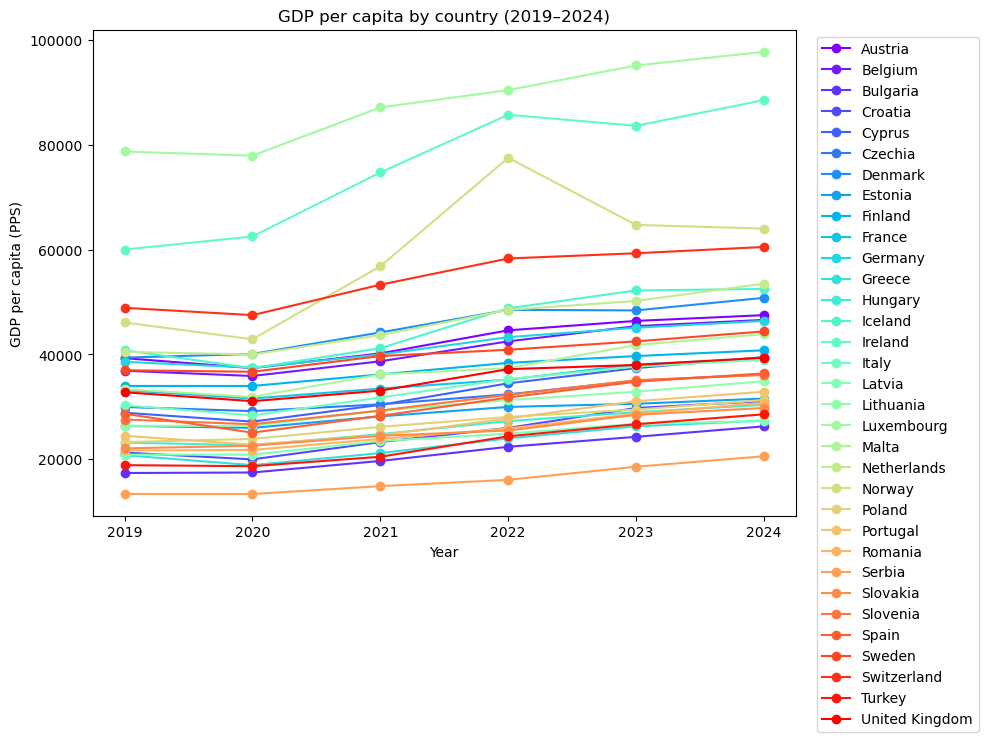

In [24]:
plt.figure(figsize=(10,7))

countries = eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):    
    
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2024[eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"] == country]
    
    plt.plot(
        country_data["Year"],
        country_data["gdp_pps"],
        marker="o",
        label=country,
        color=colors[i]
    )

plt.xlabel("Year")
plt.ylabel("GDP per capita (PPS)")
plt.title("GDP per capita by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
eu_gdp_and_to_ch_annual_plot_df_2019_2025 = eu_gdp_and_to_ch_annual_df[(eu_gdp_and_to_ch_annual_df["Year"] >= 2019) & (eu_gdp_and_to_ch_annual_df["Year"] <= 2025)]
eu_gdp_and_to_ch_annual_plot_df_2019_2025 = eu_gdp_and_to_ch_annual_plot_df_2019_2025[["Year", "Visitors' country of residence", "num_of_visitors", "gdp_pps"]].drop_duplicates()

eu_gdp_and_to_ch_annual_plot_df_2019_2025

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,188112.0,39300.0
433,2019,Belgium,208299.0,36900.0
434,2019,Bulgaria,15087.0,17400.0
435,2019,Croatia,12313.0,21300.0
436,2019,Cyprus,6671.0,28900.0
...,...,...,...,...
652,2025,Romania,55407.0,32400.0
653,2025,Slovakia,17925.0,31100.0
654,2025,Slovenia,14170.0,37700.0
655,2025,Spain,266129.0,38100.0


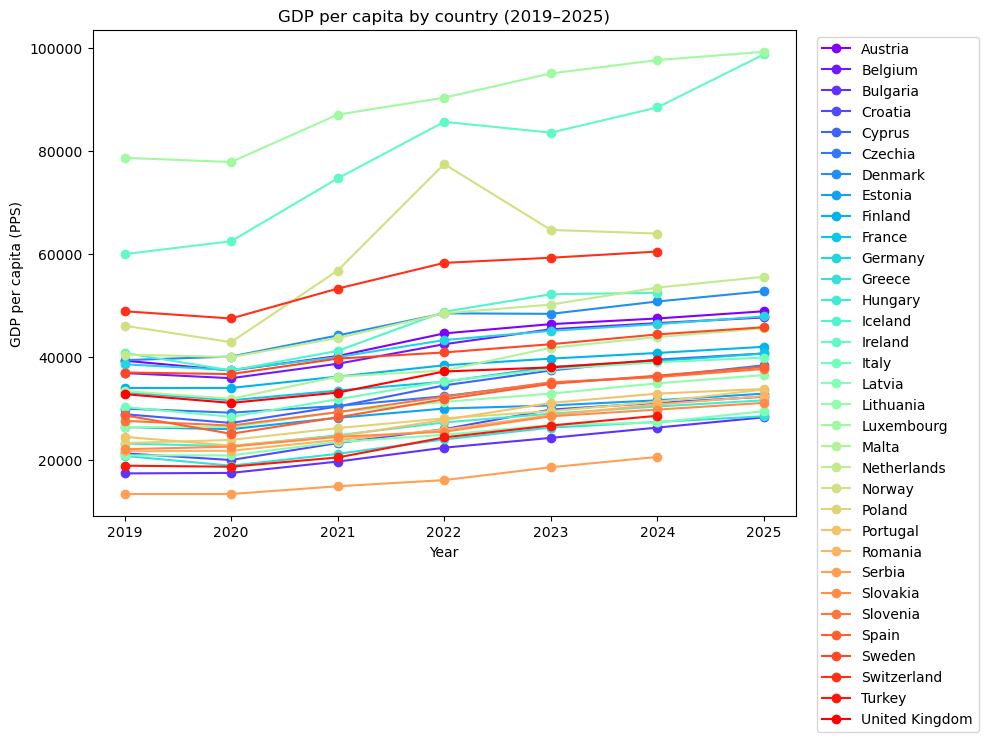

In [26]:
plt.figure(figsize=(10,7))

countries = eu_gdp_and_to_ch_annual_plot_df_2019_2025["Visitors' country of residence"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):    
    
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2025[eu_gdp_and_to_ch_annual_plot_df_2019_2025["Visitors' country of residence"] == country]
    
    plt.plot(
        country_data["Year"],
        country_data["gdp_pps"],
        marker="o",
        label=country,
        color=colors[i]
    )

plt.xlabel("Year")
plt.ylabel("GDP per capita (PPS)")
plt.title("GDP per capita by country (2019–2025)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

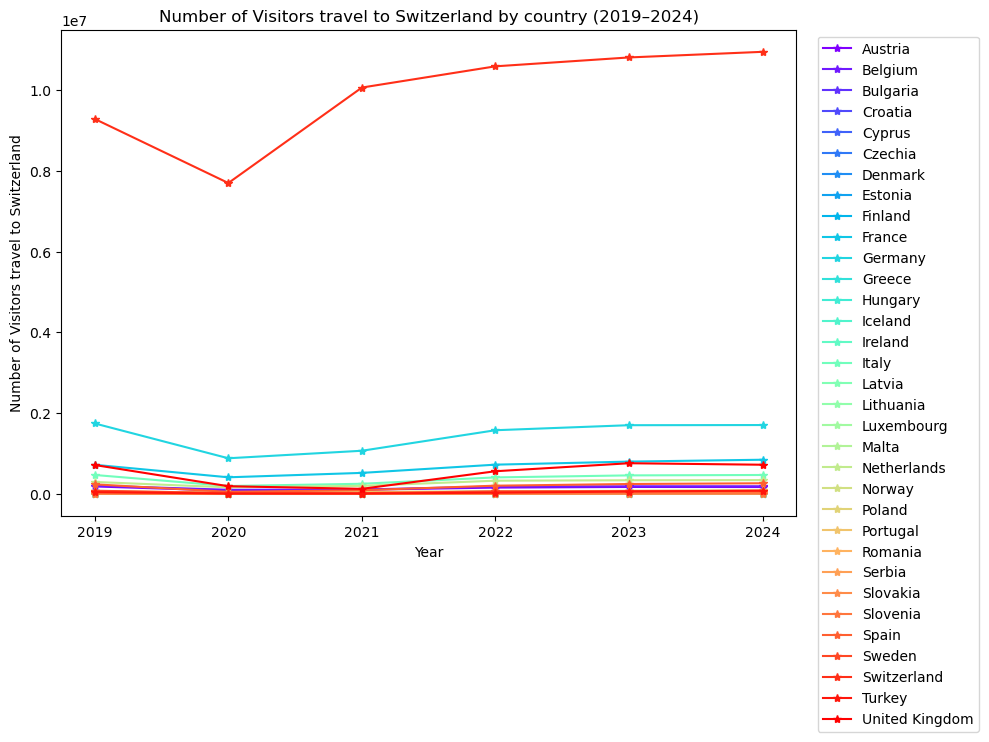

In [27]:
# set plot size
plt.figure(figsize=(10,7))

# get each country data 
for i, country in enumerate(countries):    

    # filter out data for the target country
    country_data = eu_gdp_and_to_ch_annual_plot_df_2019_2024[eu_gdp_and_to_ch_annual_plot_df_2019_2024["Visitors' country of residence"] == country]

    # plot yearly number of visitors from target country to Switzerland
    plt.plot(
        country_data["Year"],
        country_data["num_of_visitors"],
        marker="*",
        label=country,
        color=colors[i]
    )


# set plot labels and annotations
plt.xlabel("Year")
plt.ylabel("Number of Visitors travel to Switzerland")
plt.title("Number of Visitors travel to Switzerland by country (2019–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# plot
plt.tight_layout()
plt.show()

In [28]:
eu_gdp_and_to_ch_annual_plot_df_2019_2024.head()

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,188112.0,39300.0
433,2019,Belgium,208299.0,36900.0
434,2019,Bulgaria,15087.0,17400.0
435,2019,Croatia,12313.0,21300.0
436,2019,Cyprus,6671.0,28900.0


In [29]:
eu_gdp_and_to_ch_annual_plot_df_2019_2025.head()

,Year,Visitors' country of residence,num_of_visitors,gdp_pps
432,2019,Austria,188112.0,39300.0
433,2019,Belgium,208299.0,36900.0
434,2019,Bulgaria,15087.0,17400.0
435,2019,Croatia,12313.0,21300.0
436,2019,Cyprus,6671.0,28900.0


### Distance

In [31]:
import requests
from geopy.distance import geodesic

response = requests.get("https://restcountries.com/v3.1/all?fields=name,latlng")
countries = response.json()

In [32]:
for c in countries:
    if c["name"]["common"] == "Switzerland":
        print(c)
        break

{'name': {'common': 'Switzerland', 'official': 'Swiss Confederation', 'nativeName': {'fra': {'official': 'Confédération suisse', 'common': 'Suisse'}, 'gsw': {'official': 'Schweizerische Eidgenossenschaft', 'common': 'Schweiz'}, 'ita': {'official': 'Confederazione Svizzera', 'common': 'Svizzera'}, 'roh': {'official': 'Confederaziun svizra', 'common': 'Svizra'}}}, 'latlng': [47.0, 8.0]}


In [33]:
switzerland = (47.0, 8.0) # according to the above data

result = {}
for c in countries:
    name = c["name"]["common"]
    latlng = c.get("latlng", [])
    if latlng:
        # calculate the distance of each available countries(in the data) between Switzerland
        dist = geodesic(switzerland, (latlng[0], latlng[1])).km
        result[name] = {
            "lat": latlng[0],
            "long": latlng[1],
            "distance_km": round(dist, 1)
        }

with open("countries_distance.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"Total {len(result)} countries")

Total 250 countries


In [34]:
with open("countries_distance.json", "r", encoding="utf-8") as f:
    countries_distance_data = json.load(f)

# convert to data frame
df = pd.DataFrame(countries_distance_data)
print(df.shape)
print(df.head())

(3, 250)
                Anguilla  Guatemala       Gambia  Mexico  Malawi  \
lat            18.250000      15.50    13.466667    23.0   -13.5   
long          -63.166667     -90.25   -16.566667  -102.0    34.0   
distance_km  7126.300000    9374.20  4366.200000  9571.6  7185.0   

             Pitcairn Islands  Argentina          Guam  Bulgaria     Dominica  \
lat                -25.066667      -34.0     13.466667      43.0    15.416667   
long              -130.100000      -64.0    144.783333      25.0   -61.333333   
distance_km      15602.000000    11493.0  12051.600000    1408.8  7206.900000   

             ...  Lesotho  Uruguay  Burkina Faso   India  Philippines  \
lat          ...    -29.5    -33.0          13.0    20.0         13.0   
long         ...     28.5    -56.0          -2.0    77.0        122.0   
distance_km  ...   8718.9  10928.3        3883.8  6827.7      10696.0   

             Central African Republic   Sudan  Guinea-Bissau  \
lat                               7.

In [35]:
print(df.shape)
print(df.columns[:5])  # first 5 columns
print(df.index[:5])    # first 5 rows
print(df.iloc[:3, :3])

(3, 250)
Index(['Anguilla', 'Guatemala', 'Gambia', 'Mexico', 'Malawi'], dtype='object')
Index(['lat', 'long', 'distance_km'], dtype='object')
                Anguilla  Guatemala       Gambia
lat            18.250000      15.50    13.466667
long          -63.166667     -90.25   -16.566667
distance_km  7126.300000    9374.20  4366.200000


In [36]:
# test
df.loc["distance_km", "Anguilla"]   # 7126.3
df.loc["distance_km", "Guatemala"]  # 9374.2

# get all countries distance to 
distances_data_df = df.loc["distance_km", eu_countries]
print(distances_data_df)
print(len(distances_data_df)) # 51
# print(len(eu_countries)) # 51

# the closest
print(distances_data_df.idxmin(), distances_data_df.min())

# the farthest
print(distances_data_df.idxmax(), distances_data_df.max())

Albania                   1168.7
Andorra                    717.2
Armenia                   3060.8
Austria                    406.0
Azerbaijan                3226.0
Belarus                   1574.6
Belgium                    517.2
Bosnia and Herzegovina     848.9
Bulgaria                  1408.8
Croatia                    614.6
Cyprus                    2473.2
Czechia                    633.8
Denmark                   1010.8
Estonia                   1789.5
Finland                   2190.6
France                     473.7
Georgia                   2851.9
Germany                    450.8
Greece                    1443.0
Hungary                    911.8
Iceland                   2540.1
Ireland                   1322.9
Italy                      599.8
Kazakhstan                4329.1
Kosovo                    1145.2
Latvia                    1604.5
Liechtenstein              120.0
Lithuania                 1489.1
Luxembourg                 334.6
Malta                     1337.9
Moldova   

In [37]:
eu_data_df = data_df[(data_df["Month"]=="Total of the year") & (data_df["Canton"]=="Switzerland") & (data_df["Indicator"]=="Arrivals")]
eu_data_df_filtered = eu_data_df[eu_data_df["Visitors' country of residence"].isin(eu_countries)]
eu_data_df_filtered

,Year,Month,Canton,Visitors' country of residence,Indicator,value
2,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0
6,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0
8,2005,Total of the year,Switzerland,France,Arrivals,542502.0
10,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0
12,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0
...,...,...,...,...,...,...
1095266,2025,Total of the year,Switzerland,Slovakia,Arrivals,17925.0
1095268,2025,Total of the year,Switzerland,Slovenia,Arrivals,14170.0
1095270,2025,Total of the year,Switzerland,Czechia,Arrivals,55989.0
1095272,2025,Total of the year,Switzerland,Ukraine,Arrivals,42720.0


In [38]:
distances_df = distances_data_df.reset_index()
distances_df.columns = ["Visitors' country of residence", "distance_km"]

print(distances_df.head())

  Visitors' country of residence  distance_km
0                        Albania       1168.7
1                        Andorra        717.2
2                        Armenia       3060.8
3                        Austria        406.0
4                     Azerbaijan       3226.0


In [39]:
distances_df["Visitors' country of residence"].unique

<bound method Series.unique of 0                    Albania
1                    Andorra
2                    Armenia
3                    Austria
4                 Azerbaijan
5                    Belarus
6                    Belgium
7     Bosnia and Herzegovina
8                   Bulgaria
9                    Croatia
10                    Cyprus
11                   Czechia
12                   Denmark
13                   Estonia
14                   Finland
15                    France
16                   Georgia
17                   Germany
18                    Greece
19                   Hungary
20                   Iceland
21                   Ireland
22                     Italy
23                Kazakhstan
24                    Kosovo
25                    Latvia
26             Liechtenstein
27                 Lithuania
28                Luxembourg
29                     Malta
30                   Moldova
31                    Monaco
32                Montenegro
33          

In [40]:
# merge
merged = eu_data_df_filtered.merge(
    distances_df,
    on="Visitors' country of residence",
    how="left"
)

print(merged)
print(merged.shape)

     Year              Month       Canton Visitors' country of residence  \
0    2005  Total of the year  Switzerland                    Switzerland   
1    2005  Total of the year  Switzerland                        Germany   
2    2005  Total of the year  Switzerland                         France   
3    2005  Total of the year  Switzerland                          Italy   
4    2005  Total of the year  Switzerland                        Austria   
..    ...                ...          ...                            ...   
742  2025  Total of the year  Switzerland                       Slovakia   
743  2025  Total of the year  Switzerland                       Slovenia   
744  2025  Total of the year  Switzerland                        Czechia   
745  2025  Total of the year  Switzerland                        Ukraine   
746  2025  Total of the year  Switzerland                         Serbia   

    Indicator      value  distance_km  
0    Arrivals  6573945.0          0.0  
1    Ar

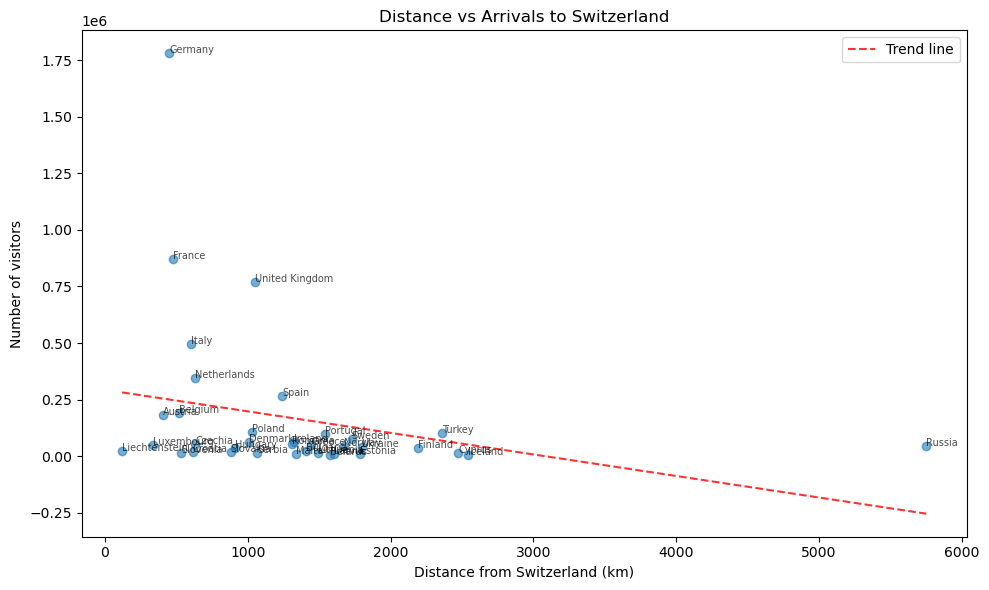

Correlation coefficient: -0.2738


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# not inlclude Switzerland, take year 2025 as example
plot_df = merged[(merged["distance_km"] > 0) & (merged["Year"]=="2025")].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(plot_df["distance_km"], plot_df["value"], alpha=0.6)

for _, row in plot_df.iterrows():
    ax.annotate(row["Visitors' country of residence"], 
                (row["distance_km"], row["value"]),
                fontsize=7, alpha=0.7)

# trend line
z = np.polyfit(plot_df["distance_km"], plot_df["value"], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df["distance_km"].min(), plot_df["distance_km"].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, label="Trend line")

ax.set_xlabel("Distance from Switzerland (km)")
ax.set_ylabel("Number of visitors")
ax.set_title("Distance vs Arrivals to Switzerland")
ax.legend()
plt.tight_layout()
plt.show()

# correlation coefficient
corr = plot_df["distance_km"].corr(plot_df["value"])
print(f"Correlation coefficient: {corr:.4f}")

In [42]:
# filter
data_df_filtered = data_df[
    (data_df["Month"] == "Total of the year") &
    (data_df["Canton"] == "Switzerland") &
    (data_df["Indicator"] == "Arrivals")
].copy()

# convert Year column to numeric
data_df_filtered["Year"] = pd.to_numeric(
    data_df_filtered["Year"],
    errors="coerce"
)

eu_gdp_and_to_ch_df["Year"] = pd.to_numeric(
    eu_gdp_and_to_ch_df["Year"],
    errors="coerce"
)

# merge
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df.merge(
    data_df_filtered,
    on=["Visitors' country of residence", "Year"],
    how="left"
)

eu_gdp_and_to_ch_df_merged

,Year,TIME_SEQ,Canton_x,Visitors' country of residence,Indicator_x,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps,Month,Canton_y,Indicator_y,value
0,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Switzerland,Arrivals,6573945.0
1,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0,Total of the year,Switzerland,Arrivals,2007203.0
2,2005,Total of the year,Switzerland,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0,Total of the year,Switzerland,Arrivals,542502.0
3,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0,Total of the year,Switzerland,Arrivals,460982.0
4,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0,Total of the year,Switzerland,Arrivals,149826.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
652,2025,Total of the year,Switzerland,Croatia,Arrivals,17968.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32300.0,Total of the year,Switzerland,Arrivals,17968.0
653,2025,Total of the year,Switzerland,Romania,Arrivals,55407.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32400.0,Total of the year,Switzerland,Arrivals,55407.0
654,2025,Total of the year,Switzerland,Slovakia,Arrivals,17925.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,31100.0,Total of the year,Switzerland,Arrivals,17925.0
655,2025,Total of the year,Switzerland,Slovenia,Arrivals,14170.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,37700.0,Total of the year,Switzerland,Arrivals,14170.0


In [43]:
# check the difference between countries names
countries_gdp = set(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())
countries_data = set(data_df_filtered["Visitors' country of residence"].unique())
print(countries_gdp)
print(countries_data)

print("in countries_gdp data：", countries_gdp - countries_data)
print("in countries_data data：", countries_data - countries_gdp)

{'Latvia', 'Romania', 'Turkey', 'Croatia', 'Netherlands', 'Ireland', 'Belgium', 'Denmark', 'Germany', 'Estonia', 'United Kingdom', 'Portugal', 'Slovakia', 'Norway', 'Hungary', 'Sweden', 'Greece', 'Iceland', 'Serbia', 'Slovenia', 'Finland', 'Czechia', 'Malta', 'Bulgaria', 'Italy', 'Poland', 'Cyprus', 'Switzerland', 'France', 'Luxembourg', 'Lithuania', 'Austria', 'Spain'}
{'Brazil', 'Estonia', 'Other South-East Asian countries', 'United Kingdom', 'Portugal', 'United Arab Emirates', 'Slovakia', 'Hungary', 'Singapore', 'South Africa', 'Switzerland', 'Luxembourg', 'Taiwan (Chinese Taipei)', 'Argentina', 'Lithuania', 'Central America, Caribbean', 'Austria', 'Japan', 'New Zealand, Oceania', 'Latvia', 'Croatia', 'Netherlands', 'Ireland', 'Germany', 'Mexico', 'Thailand', 'Other South American countries', 'Sweden', 'Other African countries', 'Slovenia', 'South Korea', 'Philippines', 'Malta', 'Italy', 'Indonesia', 'Spain', 'Chile', 'Liechtenstein', 'Romania', 'Turkey', 'Denmark', 'Gulf States', '

In [44]:
print(eu_gdp_and_to_ch_df["Visitors' country of residence"].unique())

['Switzerland' 'Germany' 'France' 'Italy' 'Austria' 'United Kingdom'
 'Ireland' 'Netherlands' 'Belgium' 'Luxembourg' 'Denmark' 'Sweden'
 'Norway' 'Finland' 'Spain' 'Portugal' 'Greece' 'Turkey' 'Iceland'
 'Poland' 'Hungary' 'Bulgaria' 'Croatia' 'Romania' 'Slovakia' 'Slovenia'
 'Czechia' 'Malta' 'Cyprus' 'Estonia' 'Latvia' 'Lithuania' 'Serbia']


In [45]:
print(data_df_filtered[data_df_filtered["Visitors' country of residence"].isin(eu_countries)]["Visitors' country of residence"].unique())

['Switzerland' 'Germany' 'France' 'Italy' 'Austria' 'United Kingdom'
 'Ireland' 'Netherlands' 'Belgium' 'Luxembourg' 'Denmark' 'Sweden'
 'Norway' 'Finland' 'Spain' 'Portugal' 'Greece' 'Turkey' 'Liechtenstein'
 'Iceland' 'Poland' 'Hungary' 'Belarus' 'Bulgaria' 'Croatia' 'Romania'
 'Russia' 'Slovakia' 'Slovenia' 'Czechia' 'Ukraine' 'Malta' 'Cyprus'
 'Estonia' 'Latvia' 'Lithuania' 'Serbia']


In [46]:
print("gdp years:", sorted(eu_gdp_and_to_ch_df["Year"].unique()))
print("data years:", sorted(data_df_filtered["Year"].unique()))

gdp years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
data years: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [47]:
eu_gdp_and_to_ch_df_merged

,Year,TIME_SEQ,Canton_x,Visitors' country of residence,Indicator_x,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps,Month,Canton_y,Indicator_y,value
0,2005,Total of the year,Switzerland,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,Total of the year,Switzerland,Arrivals,6573945.0
1,2005,Total of the year,Switzerland,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0,Total of the year,Switzerland,Arrivals,2007203.0
2,2005,Total of the year,Switzerland,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0,Total of the year,Switzerland,Arrivals,542502.0
3,2005,Total of the year,Switzerland,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0,Total of the year,Switzerland,Arrivals,460982.0
4,2005,Total of the year,Switzerland,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0,Total of the year,Switzerland,Arrivals,149826.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
652,2025,Total of the year,Switzerland,Croatia,Arrivals,17968.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32300.0,Total of the year,Switzerland,Arrivals,17968.0
653,2025,Total of the year,Switzerland,Romania,Arrivals,55407.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32400.0,Total of the year,Switzerland,Arrivals,55407.0
654,2025,Total of the year,Switzerland,Slovakia,Arrivals,17925.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,31100.0,Total of the year,Switzerland,Arrivals,17925.0
655,2025,Total of the year,Switzerland,Slovenia,Arrivals,14170.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,37700.0,Total of the year,Switzerland,Arrivals,14170.0


In [48]:
with open("eu_gdp_and_to_ch_df_merged.json", "w", encoding="utf-8") as f:
    json.dump(eu_gdp_and_to_ch_df_merged.to_dict("records"), f, ensure_ascii=False, indent=2)

In [49]:
with open("eu_gdp_and_to_ch_df_merged.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.head())

   Year           TIME_SEQ     Canton_x Visitors' country of residence  \
0  2005  Total of the year  Switzerland                    Switzerland   
1  2005  Total of the year  Switzerland                        Germany   
2  2005  Total of the year  Switzerland                         France   
3  2005  Total of the year  Switzerland                          Italy   
4  2005  Total of the year  Switzerland                        Austria   

  Indicator_x  num_of_visitors              indic_ppp  \
0    Arrivals        6573945.0  EXP_PPS_EU27_2020_HAB   
1    Arrivals        2007203.0  EXP_PPS_EU27_2020_HAB   
2    Arrivals         542502.0  EXP_PPS_EU27_2020_HAB   
3    Arrivals         460982.0  EXP_PPS_EU27_2020_HAB   
4    Arrivals         149826.0  EXP_PPS_EU27_2020_HAB   

              Purchasing power parities indicator ppp_cat18 unit  \
0  Real expenditure per capita (in PPS_EU27_2020)       GDP   PC   
1  Real expenditure per capita (in PPS_EU27_2020)       GDP   PC   
2  Real 

In [50]:
# drop na
tmp = df[['Year',
          "Visitors' country of residence",
          'gdp_pps',
          'num_of_visitors']].dropna()

# correlation each year
corr_by_year = (
    tmp.groupby('Year')
       .apply(
           lambda x: x['gdp_pps'].corr(x['num_of_visitors']),
           include_groups=False
       )
       .reset_index(name='corr_gdp_visitors')
)

print(corr_by_year)

    Year  corr_gdp_visitors
0   2005           0.228434
1   2006           0.226021
2   2007           0.245022
3   2008           0.242315
4   2009           0.269190
5   2010           0.295784
6   2011           0.300576
7   2012           0.302806
8   2013           0.304087
9   2014           0.305550
10  2015           0.286027
11  2016           0.280640
12  2017           0.259786
13  2018           0.258047
14  2019           0.251258
15  2020           0.234729
16  2021           0.223522
17  2022           0.209334
18  2023           0.215922
19  2024           0.206541
20  2025           0.061020


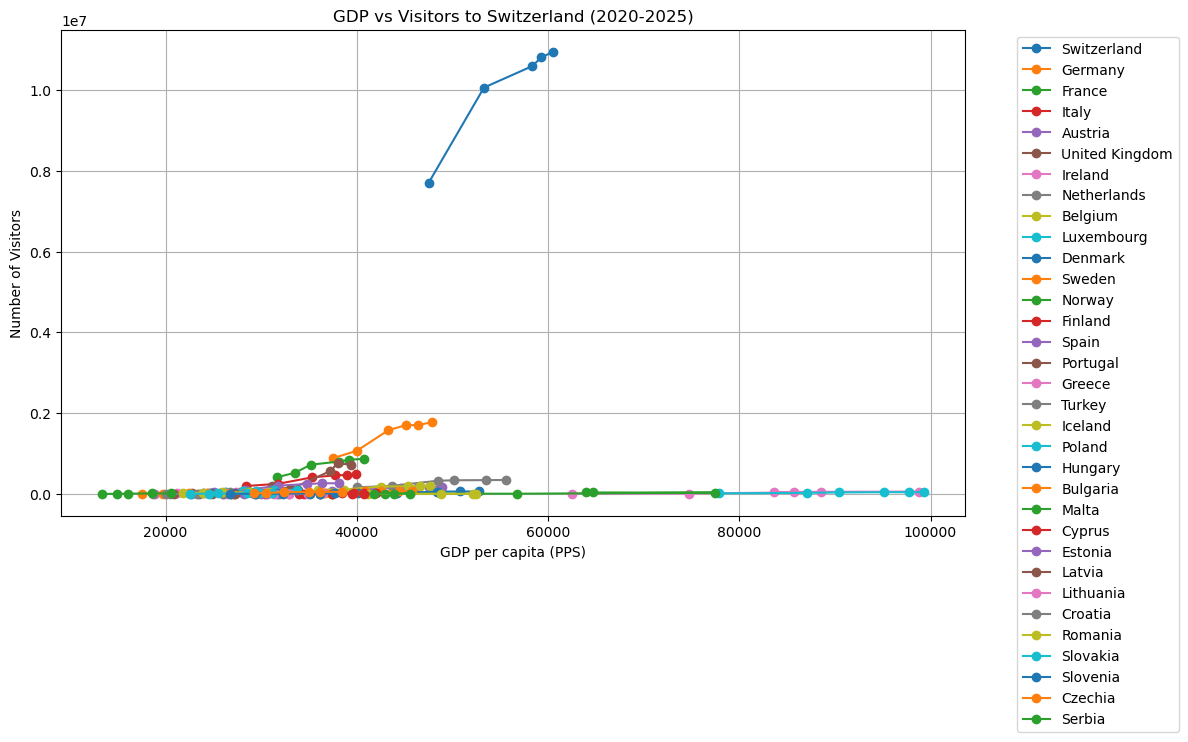

In [51]:
df_filtered = df[['Year',
                  "Visitors' country of residence",
                  'gdp_pps',
                  'num_of_visitors']].dropna()

# keep 2020~2025
df_filtered = df_filtered[
    (df_filtered['Year'] >= 2020) &
    (df_filtered['Year'] <= 2025)
]

plt.figure(figsize=(12,7))

# each country line plot
for country in df_filtered["Visitors' country of residence"].unique():

    country_data = df_filtered[
        df_filtered["Visitors' country of residence"] == country
    ].sort_values('Year')

    plt.plot(
        country_data['gdp_pps'],          # X-axis GDP
        country_data['num_of_visitors'],  # Y-axis Visitors
        marker='o',
        label=country
    )

plt.title('GDP vs Visitors to Switzerland (2020-2025)')
plt.xlabel('GDP per capita (PPS)')
plt.ylabel('Number of Visitors')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [52]:
print(eu_gdp_and_to_ch_df_merged.columns.tolist())

['Year', 'TIME_SEQ', 'Canton_x', "Visitors' country of residence", 'Indicator_x', 'num_of_visitors', 'indic_ppp', 'Purchasing power parities indicator', 'ppp_cat18', 'unit', 'Unit of measure', 'gdp_pps', 'Month', 'Canton_y', 'Indicator_y', 'value']


In [53]:
print(eu_gdp_and_to_ch_df_merged["Canton_x"].unique())
print(eu_gdp_and_to_ch_df_merged["Canton_y"].unique())
print(eu_gdp_and_to_ch_df_merged["Indicator_x"].unique())
print(eu_gdp_and_to_ch_df_merged["Indicator_y"].unique())

['Switzerland']
['Switzerland']
['Arrivals']
['Arrivals']


In [54]:
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df_merged.drop(columns=["Canton_y", "Indicator_y", "Canton_x", "Month", "TIME_SEQ"])
eu_gdp_and_to_ch_df_merged = eu_gdp_and_to_ch_df_merged.rename(columns={"Indicator_x": "Indicator"})

print(eu_gdp_and_to_ch_df_merged.columns.tolist())
print(eu_gdp_and_to_ch_df_merged.head())

['Year', "Visitors' country of residence", 'Indicator', 'num_of_visitors', 'indic_ppp', 'Purchasing power parities indicator', 'ppp_cat18', 'unit', 'Unit of measure', 'gdp_pps', 'value']
   Year Visitors' country of residence Indicator  num_of_visitors  \
0  2005                    Switzerland  Arrivals        6573945.0   
1  2005                        Germany  Arrivals        2007203.0   
2  2005                         France  Arrivals         542502.0   
3  2005                          Italy  Arrivals         460982.0   
4  2005                        Austria  Arrivals         149826.0   

               indic_ppp             Purchasing power parities indicator  \
0  EXP_PPS_EU27_2020_HAB  Real expenditure per capita (in PPS_EU27_2020)   
1  EXP_PPS_EU27_2020_HAB  Real expenditure per capita (in PPS_EU27_2020)   
2  EXP_PPS_EU27_2020_HAB  Real expenditure per capita (in PPS_EU27_2020)   
3  EXP_PPS_EU27_2020_HAB  Real expenditure per capita (in PPS_EU27_2020)   
4  EXP_PPS_EU27_20

In [55]:
eu_gdp_and_to_ch_df_merged # final eu_gdp_and_to_ch_df_merged

,Year,Visitors' country of residence,Indicator,num_of_visitors,indic_ppp,Purchasing power parities indicator,ppp_cat18,unit,Unit of measure,gdp_pps,value
0,2005,Switzerland,Arrivals,6573945.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,34300.0,6573945.0
1,2005,Germany,Arrivals,2007203.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,26800.0,2007203.0
2,2005,France,Arrivals,542502.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,25000.0,542502.0
3,2005,Italy,Arrivals,460982.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,24700.0,460982.0
4,2005,Austria,Arrivals,149826.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,28500.0,149826.0
...,...,...,...,...,...,...,...,...,...,...,...
652,2025,Croatia,Arrivals,17968.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32300.0,17968.0
653,2025,Romania,Arrivals,55407.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,32400.0,55407.0
654,2025,Slovakia,Arrivals,17925.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,31100.0,17925.0
655,2025,Slovenia,Arrivals,14170.0,EXP_PPS_EU27_2020_HAB,Real expenditure per capita (in PPS_EU27_2020),GDP,PC,Percentage,37700.0,14170.0


plot_df rows: 225


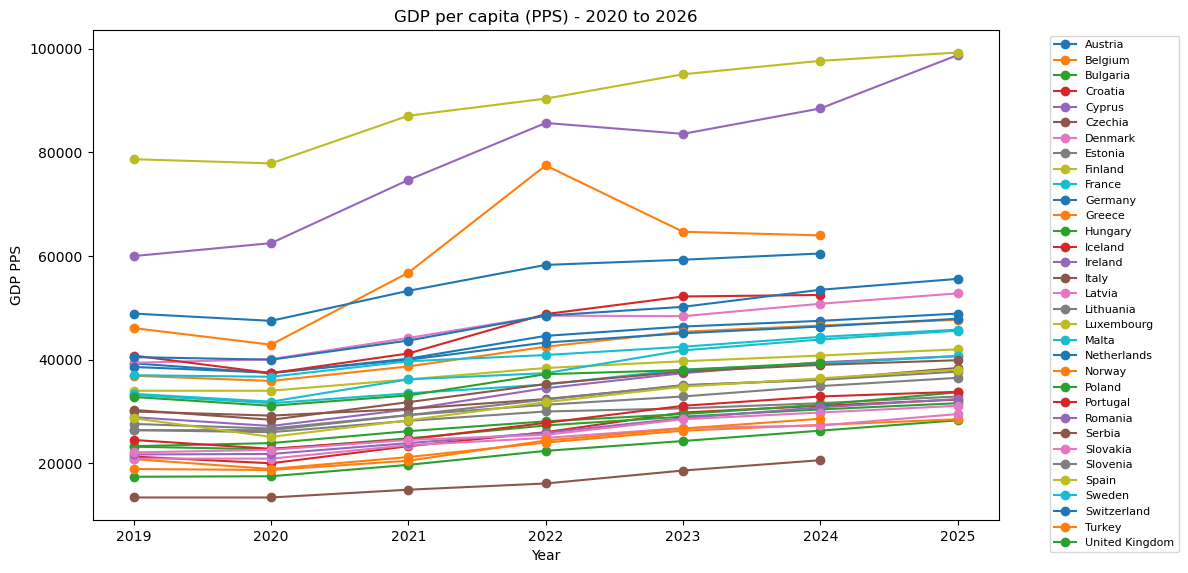

In [56]:
years_to_plot = list(range(2019, 2026))

plot_df = eu_gdp_and_to_ch_df_merged[
    eu_gdp_and_to_ch_df_merged["Year"].isin(years_to_plot)
].dropna(subset=["gdp_pps"])

print(f"plot_df rows: {len(plot_df)}")

fig, ax = plt.subplots(figsize=(12, 6))

for country, group in plot_df.groupby("Visitors' country of residence"):
    group = group.sort_values("Year")
    ax.plot(group["Year"], group["gdp_pps"], marker="o", label=country)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(x))))

ax.set_xlabel("Year")
ax.set_ylabel("GDP PPS")
ax.set_title("GDP per capita (PPS) - 2020 to 2026")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [57]:
print(merged[["Visitors' country of residence", "distance_km", "value"]].to_dict("records"))
countries_distances_vs_visitors = merged[["Visitors' country of residence", "distance_km", "value"]].to_dict("records")

[{"Visitors' country of residence": 'Switzerland', 'distance_km': 0.0, 'value': 6573945.0}, {"Visitors' country of residence": 'Germany', 'distance_km': 450.8, 'value': 2007203.0}, {"Visitors' country of residence": 'France', 'distance_km': 473.7, 'value': 542502.0}, {"Visitors' country of residence": 'Italy', 'distance_km': 599.8, 'value': 460982.0}, {"Visitors' country of residence": 'Austria', 'distance_km': 406.0, 'value': 149826.0}, {"Visitors' country of residence": 'United Kingdom', 'distance_km': 1051.5, 'value': 709155.0}, {"Visitors' country of residence": 'Ireland', 'distance_km': 1322.9, 'value': 25278.0}, {"Visitors' country of residence": 'Netherlands', 'distance_km': 632.8, 'value': 312546.0}, {"Visitors' country of residence": 'Belgium', 'distance_km': 517.2, 'value': 207644.0}, {"Visitors' country of residence": 'Luxembourg', 'distance_km': 334.6, 'value': 35309.0}, {"Visitors' country of residence": 'Denmark', 'distance_km': 1010.8, 'value': 49296.0}, {"Visitors' coun

In [58]:
with open("countries_distances_vs_visitors.json", "w", encoding="utf-8") as f:
    json.dump(countries_distances_vs_visitors, f, ensure_ascii=False, indent=2)